#### Autor: Rainiero Mendoza de Jesus ***6/4/2026***

In [1]:
# Import the libraries

import csv
from pathlib import Path as Path
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# We extract the data from the csv file

path = Path('../data/punta_cana.csv')
lines = path.read_text(encoding='utf-8').splitlines()
reader = csv.reader(lines)
headers_row = next(reader)

In [3]:
# We explore the fields that our csv file has

for index,x in enumerate(headers_row):
    print(index, x)

0 STATION
1 NAME
2 LATITUDE
3 LONGITUDE
4 ELEVATION
5 DATE
6 TAVG
7 TAVG_ATTRIBUTES
8 TMAX
9 TMAX_ATTRIBUTES
10 TMIN
11 TMIN_ATTRIBUTES


In [4]:
# We extract the columns we want

date = headers_row.index('DATE')
tavg = headers_row.index('TAVG')
tmax = headers_row.index('TMAX')
tmin = headers_row.index('TMIN')
station = headers_row.index('STATION')
name = headers_row.index('NAME')

In [5]:
data = []

for i in reader:

    date_current = datetime.strptime(i[date], '%Y-%m-%d')
    year_current = int(date_current.strftime('%Y'))
    
    station_current = i[station]
    tavg_value = i[tavg]
    tmax_value = i[tmax]
    tmin_value = i[tmin]

    if station_current != 'DRM00078479':
        break

    if data:

        last_dict = data[-1]

        if year_current == last_dict['Year']:

            if tavg_value and tavg_value != 'NaN':
                last_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                last_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                last_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        else:

            new_dict = {
                'Year': year_current,
                'ANUAL TAVG LIST': [],
                'ANUAL TMAX LIST': [],
                'ANUAL TMIN LIST': []
            }

            if tavg_value and tavg_value != 'NaN':
                new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

            data.append(new_dict)

    else:

        new_dict = {
            'Year': year_current,
            'ANUAL TAVG LIST': [],
            'ANUAL TMAX LIST': [],
            'ANUAL TMIN LIST': []
        }

        if tavg_value and tavg_value != 'NaN':
            new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

        if tmax_value and tmax_value != 'NaN':
            new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

        if tmin_value and tmin_value != 'NaN':
            new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        data.append(new_dict)

In [6]:
# We verify the structure we created

print(data[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [78.0, 78.0, 78.0, 78.0, 78.0, 77.0, 79.0, 78.0, 78.0, 77.0, 78.0, 79.0, 77.0, 78.0, 77.0, 73.0, 75.0, 74.0, 74.0, 73.0, 74.0, 76.0, 78.0, 79.0, 80.0, 79.0, 78.0, 78.0, 79.0, 79.0, 78.0, 79.0, 79.0, 79.0, 77.0, 77.0, 76.0, 79.0, 79.0, 78.0, 80.0, 79.0, 80.0, 79.0, 79.0, 77.0, 79.0, 78.0, 78.0, 79.0, 76.0, 78.0, 77.0, 78.0, 76.0, 79.0, 76.0, 78.0, 77.0, 77.0, 78.0, 78.0, 78.0, 77.0, 77.0, 78.0, 78.0, 78.0, 79.0, 78.0, 80.0, 79.0, 78.0, 78.0, 79.0, 78.0, 79.0, 78.0, 78.0, 77.0, 77.0, 79.0, 78.0, 82.0, 81.0, 82.0, 82.0, 80.0, 81.0, 81.0, 80.0, 78.0, 80.0, 80.0, 81.0, 81.0, 80.0, 82.0, 81.0, 81.0, 81.0, 81.0, 81.0, 81.0, 80.0, 80.0, 80.0, 80.0, 82.0, 82.0, 81.0, 83.0, 82.0, 81.0, 83.0, 82.0, 81.0, 82.0, 80.0, 82.0, 81.0, 81.0, 81.0, 79.0, 81.0, 82.0, 82.0, 81.0, 75.0, 81.0, 82.0, 82.0, 82.0, 82.0, 80.0, 80.0, 81.0, 82.0, 82.0, 82.0, 83.0, 84.0, 84.0, 84.0, 83.0, 85.0, 84.0, 83.0, 84.0, 84.0, 85.0, 84.0, 83.0, 85.0, 85.0, 84.0, 84.0, 85.0, 85.0, 83.0, 84.0

In [7]:

data_00_12 = data[0:13:1]
data_13_24 = data[13:26:1]

print(data_00_12[:2])
print(data_13_24[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [78.0, 78.0, 78.0, 78.0, 78.0, 77.0, 79.0, 78.0, 78.0, 77.0, 78.0, 79.0, 77.0, 78.0, 77.0, 73.0, 75.0, 74.0, 74.0, 73.0, 74.0, 76.0, 78.0, 79.0, 80.0, 79.0, 78.0, 78.0, 79.0, 79.0, 78.0, 79.0, 79.0, 79.0, 77.0, 77.0, 76.0, 79.0, 79.0, 78.0, 80.0, 79.0, 80.0, 79.0, 79.0, 77.0, 79.0, 78.0, 78.0, 79.0, 76.0, 78.0, 77.0, 78.0, 76.0, 79.0, 76.0, 78.0, 77.0, 77.0, 78.0, 78.0, 78.0, 77.0, 77.0, 78.0, 78.0, 78.0, 79.0, 78.0, 80.0, 79.0, 78.0, 78.0, 79.0, 78.0, 79.0, 78.0, 78.0, 77.0, 77.0, 79.0, 78.0, 82.0, 81.0, 82.0, 82.0, 80.0, 81.0, 81.0, 80.0, 78.0, 80.0, 80.0, 81.0, 81.0, 80.0, 82.0, 81.0, 81.0, 81.0, 81.0, 81.0, 81.0, 80.0, 80.0, 80.0, 80.0, 82.0, 82.0, 81.0, 83.0, 82.0, 81.0, 83.0, 82.0, 81.0, 82.0, 80.0, 82.0, 81.0, 81.0, 81.0, 79.0, 81.0, 82.0, 82.0, 81.0, 75.0, 81.0, 82.0, 82.0, 82.0, 82.0, 80.0, 80.0, 81.0, 82.0, 82.0, 82.0, 83.0, 84.0, 84.0, 84.0, 83.0, 85.0, 84.0, 83.0, 84.0, 84.0, 85.0, 84.0, 83.0, 85.0, 85.0, 84.0, 84.0, 85.0, 85.0, 83.0, 84.0

In [8]:
# We create lists where we store the data already processed and ready to graph

years, anual_tmaxs, anual_tmins = [], [], []
anual_tavgs = []

years_parte1, tmaxs_parte1, tmins_parte1 = [], [], []
tavgs_parte1 = []

years_parte2, tmaxs_parte2, tmins_parte2 = [], [], []
tavgs_parte2 = []

In [9]:
# Once the data is grouped, we perform the desired operations

def cambio_lista(value_list, value_years, value_tmax, value_tmin, value_tavg):
    for i in value_list:
        year = i['Year']
        value_years.append(year)

        tmax = i['ANUAL TMAX LIST']
        tmax_len = len(tmax)
        valor_final = sum(tmax)/tmax_len
        value_tmax.append(valor_final)

        tmin = i['ANUAL TMIN LIST']
        tmin_len = len(tmin)
        valor_mins = sum(tmin)/tmin_len
        value_tmin.append(valor_mins)

        tavg = i['ANUAL TAVG LIST']
        tavg_len = len(tavg)
        valor_tavg = sum(tavg)/tavg_len
        value_tavg.append(valor_tavg)

In [10]:
cambio_lista(value_list=data, value_years=years,value_tmax=anual_tmaxs, value_tmin=anual_tmins, value_tavg=anual_tavgs)
cambio_lista(value_list=data_00_12, value_years=years_parte1,value_tmax=tmaxs_parte1, value_tmin=tmins_parte1, value_tavg=tavgs_parte1)
cambio_lista(value_list=data_13_24, value_years=years_parte2,value_tmax=tmaxs_parte2, value_tmin=tmins_parte2, value_tavg=tavgs_parte2)

In [11]:
# Exploramos las listas para verificar 

print(years)
print(anual_tmaxs)
print(anual_tmins)
print(anual_tavgs)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[86.61261261261261, 87.71875, 87.5060975609756, 88.53191489361703, 88.48780487804878, 89.2720588235294, 88.03529411764706, 87.70614035087719, 86.39492753623189, 86.09486166007905, 87.38039215686274, 86.42361111111111, 86.63533834586467, 87.10593220338983, 87.6600790513834, 87.65283018867925, 86.60975609756098, 86.13448275862069, 86.13029315960912, 87.26388888888889, 87.7190635451505, 87.36789297658864, 87.52413793103449, 88.38888888888889, 88.896875]
[72.34234234234235, 73.021875, 73.0, 72.34954407294833, 70.83739837398375, 73.73529411764706, 73.07843137254902, 74.16666666666667, 72.76449275362319, 72.49802371541502, 72.84705882352941, 72.35069444444444, 72.87218045112782, 74.10169491525424, 73.52173913043478, 73.79622641509434, 73.06968641114983, 72.61724137931034, 72.85667752442997, 73.17361111111111, 73.75919732441471, 72.956521739130

In [12]:
print(years_parte1)
print(tmaxs_parte1)
print(tmins_parte1)
print(tavgs_parte1)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
[86.61261261261261, 87.71875, 87.5060975609756, 88.53191489361703, 88.48780487804878, 89.2720588235294, 88.03529411764706, 87.70614035087719, 86.39492753623189, 86.09486166007905, 87.38039215686274, 86.42361111111111, 86.63533834586467]
[72.34234234234235, 73.021875, 73.0, 72.34954407294833, 70.83739837398375, 73.73529411764706, 73.07843137254902, 74.16666666666667, 72.76449275362319, 72.49802371541502, 72.84705882352941, 72.35069444444444, 72.87218045112782]
[81.5567867036011, 82.63157894736842, 82.5576923076923, 83.3659217877095, 82.53443526170798, 84.10055865921788, 82.07988980716253, 82.22191780821917, 80.65193370165746, 80.06575342465753, 79.98356164383561, 79.6, 79.79781420765028]


In [13]:
print(years_parte2)
print(tmaxs_parte2)
print(tmins_parte2)
print(tavgs_parte2)

[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[87.10593220338983, 87.6600790513834, 87.65283018867925, 86.60975609756098, 86.13448275862069, 86.13029315960912, 87.26388888888889, 87.7190635451505, 87.36789297658864, 87.52413793103449, 88.38888888888889, 88.896875]
[74.10169491525424, 73.52173913043478, 73.79622641509434, 73.06968641114983, 72.61724137931034, 72.85667752442997, 73.17361111111111, 73.75919732441471, 72.95652173913044, 72.56206896551724, 72.45679012345678, 73.10625]
[80.14520547945206, 80.0027397260274, 80.51780821917808, 80.12295081967213, 79.43835616438356, 79.55616438356165, 80.24657534246575, 80.74590163934427, 80.48342541436465, 80.15342465753425, 80.98356164383561, 81.26966292134831]


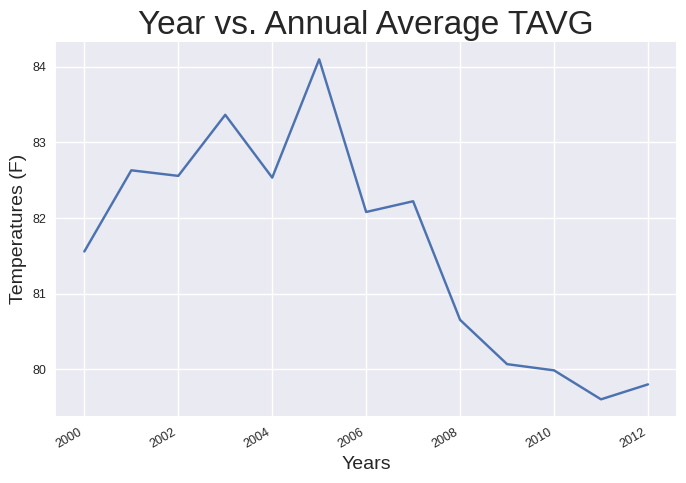

In [14]:
# Make a plot, 2000-2012 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte1, tavgs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

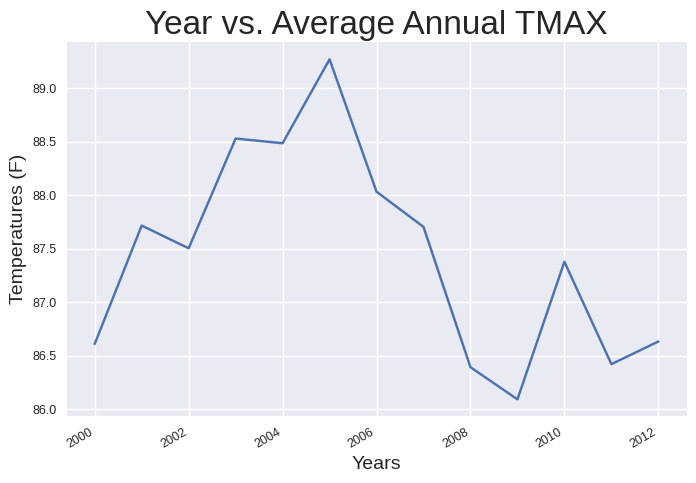

In [15]:
# Make a plots, 2000-2012 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmaxs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

In [ ]:
# Make a plot, 2000-2012 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmins_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

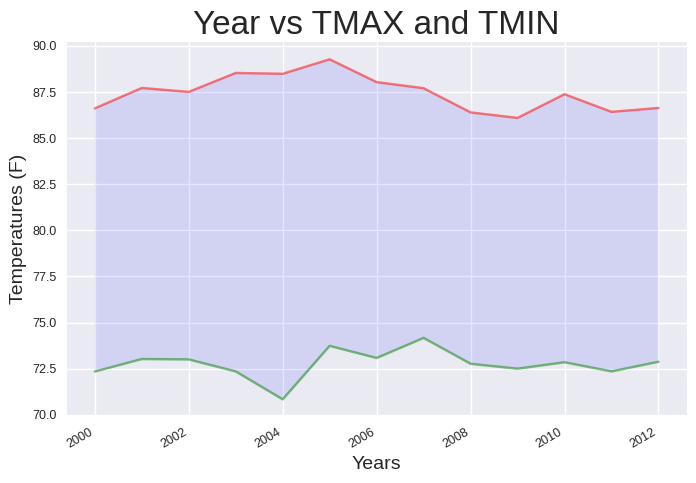

In [16]:
# Make a plot, 2000-2012 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte1, tmaxs_parte1, color='red', alpha=0.5)
ax.plot(years_parte1, tmins_parte1, color='green', alpha=0.5)
ax.fill_between(years_parte1, tmaxs_parte1, tmins_parte1, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

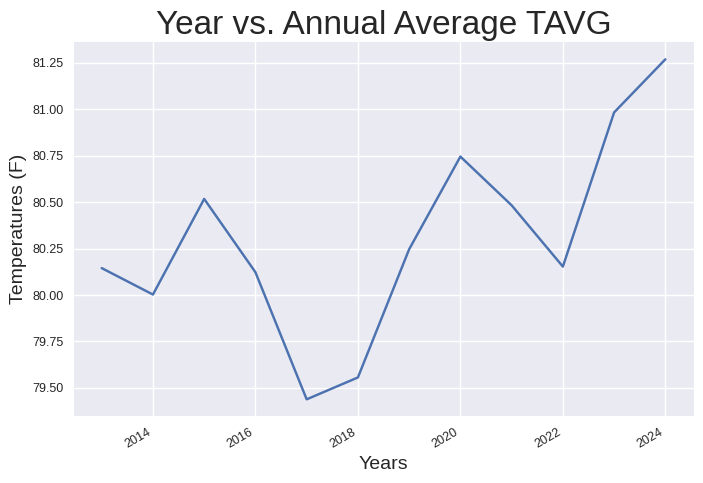

In [17]:
# Make a plot, 2013-2024 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte2, tavgs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

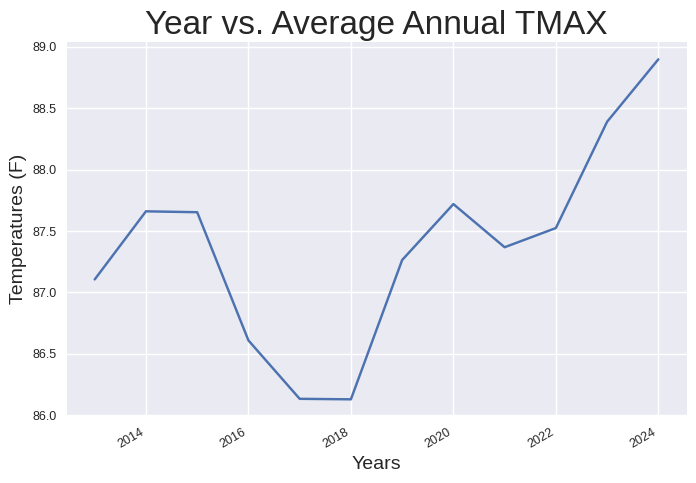

In [18]:
# Make a plots, 2013-2024 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmaxs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

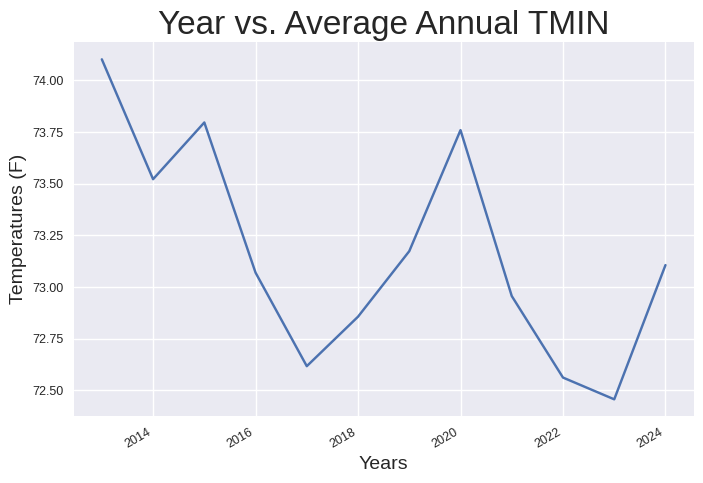

In [19]:
# Make a plot, 2013-2024 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmins_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

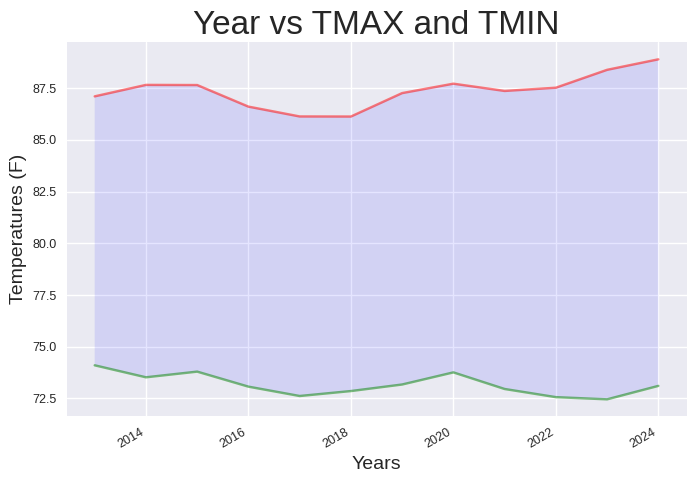

In [20]:
# Make a plot, 2013-2024 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte2, tmaxs_parte2, color='red', alpha=0.5)
ax.plot(years_parte2, tmins_parte2, color='green', alpha=0.5)
ax.fill_between(years_parte2, tmaxs_parte2, tmins_parte2, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

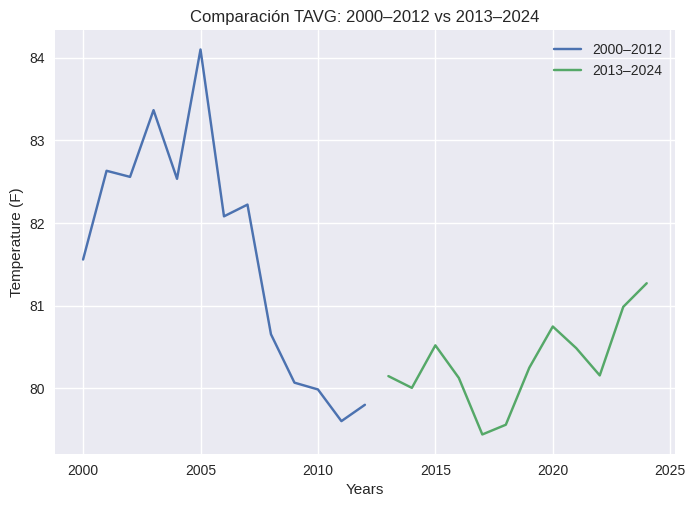

In [21]:
# Comparación TAVG: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tavgs_parte1, label='2000–2012')
ax.plot(years_parte2, tavgs_parte2, label='2013–2024')

ax.set_title('Comparación TAVG: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

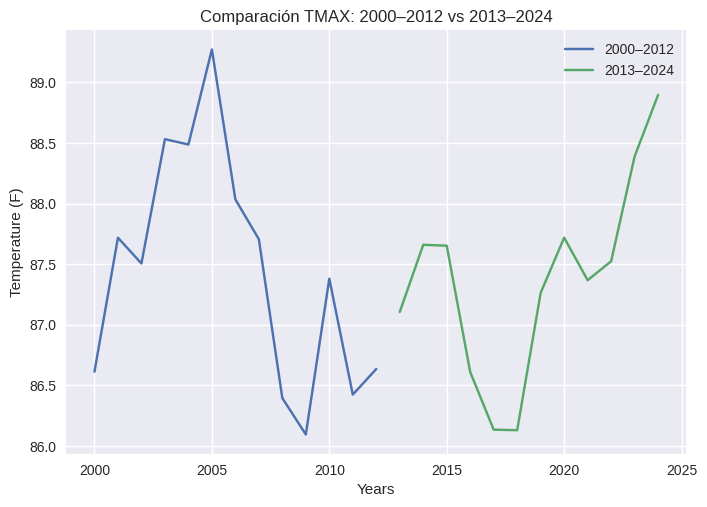

In [22]:
# Comparación TMAX: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmaxs_parte1, label='2000–2012')
ax.plot(years_parte2, tmaxs_parte2, label='2013–2024')

ax.set_title('Comparación TMAX: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

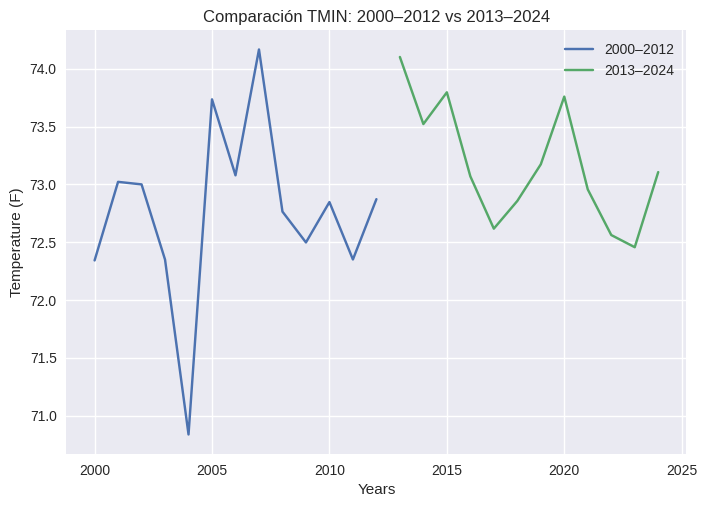

In [24]:
# Comparación TMIN: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmins_parte1, label='2000–2012')
ax.plot(years_parte2, tmins_parte2, label='2013–2024')

ax.set_title('Comparación TMIN: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()